In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import os
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [15]:
# Load datasets
df = pd.read_csv("Summary_of_Results_3_18_2026.csv")
unemp = pd.read_csv("US_unemployment_rate.csv")
fed_rate = pd.read_csv("avg Federal Funds Effective Rate.csv")

# Basic cleaning for failed banks
df = df[df['RESTYPE'] == 'FAILURE'].copy()
df = df.dropna(subset=['COST', 'QBFASSET', 'FAILDATE'])
df = df[(df['COST'] != 0) & (df['QBFASSET'] > 0)]

# Target variable (LGD)
df['LGD'] = df['COST'] / df['QBFASSET']

# Dates and State extraction
df['FAILDATE'] = pd.to_datetime(df['FAILDATE'])
df['YEAR'] = df['FAILDATE'].dt.year
df['STATE'] = df['CITYST'].str[-2:]

# Macroeconomic data processing
unemp['YEAR'] = pd.to_datetime(unemp['observation_date']).dt.year
annual_unemp = unemp.groupby('YEAR')['UNRATE'].mean().reset_index()

fed_rate['YEAR'] = pd.to_datetime(fed_rate['DATE']).dt.year
annual_fed = fed_rate.groupby('YEAR')['VALUE'].mean().reset_index().rename(columns={'VALUE': 'FEDFUNDS'})

df = df.merge(annual_unemp, on='YEAR', how='left')
df = df.merge(annual_fed, on='YEAR', how='left')

# Feature Engineering
df['Deposit_to_Asset_Ratio'] = df['QBFDEP'] / df['QBFASSET']

df = df.sort_values('FAILDATE')
df['State_Failures_Last_12M'] = 0
for i in range(len(df)):
    current_state = df.iloc[i]['STATE']
    current_date = df.iloc[i]['FAILDATE']
    window_start = current_date - pd.Timedelta(days=365)
    count = df[(df['STATE'] == current_state) & 
               (df['FAILDATE'] < current_date) & 
               (df['FAILDATE'] >= window_start)].shape[0]
    df.at[df.index[i], 'State_Failures_Last_12M'] = count

df_final = df.dropna(subset=['UNRATE', 'FEDFUNDS', 'LGD']).copy()

# Binary target for classification tasks
df_final['LGD_class'] = (df_final['LGD'] > 0.2).astype(int)
print(f"Data ready: {df_final.shape[0]} banks analyzed.")

KeyboardInterrupt: 

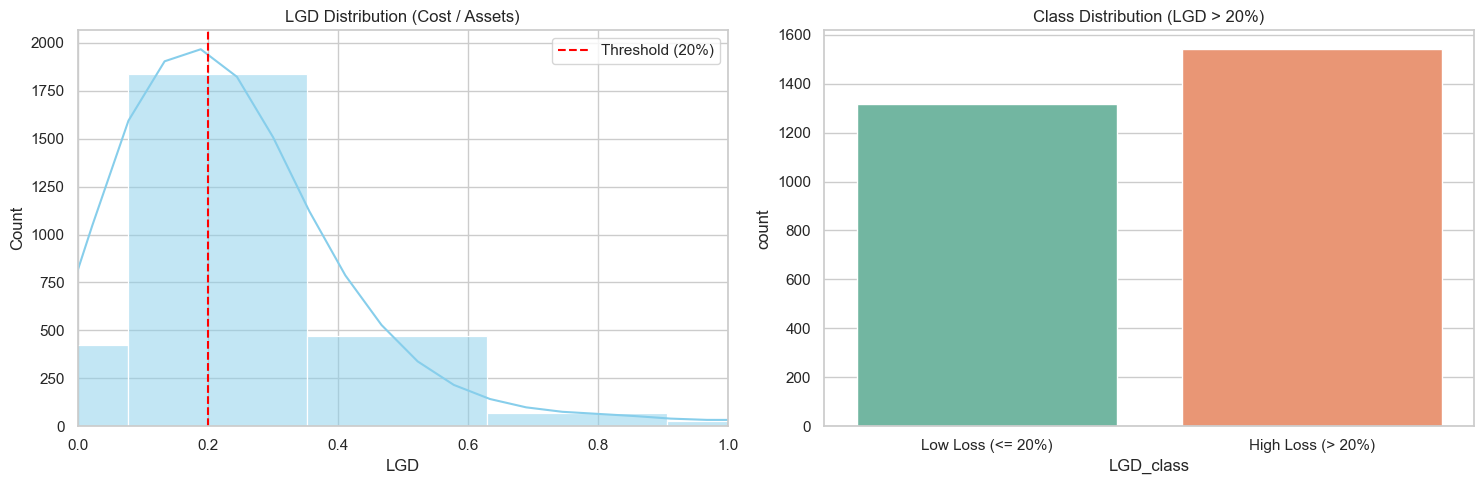

In [ ]:
# Visualizing the target variable distribution
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_final['LGD'], bins=40, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('LGD Distribution (Cost / Assets)')
ax[0].set_xlim(0, 1)
ax[0].axvline(0.2, color='red', linestyle='--', label='Threshold (20%)')
ax[0].legend()

sns.countplot(data=df_final, x='LGD_class', hue='LGD_class', ax=ax[1], palette='Set2', legend=False)
ax[1].set_title('Class Distribution (LGD > 20%)')

# --- L'AJOUT EST ICI ---
ax[1].set_xticks([0, 1]) 
ax[1].set_xticklabels(['Low Loss (<= 20%)', 'High Loss (> 20%)'])
# -----------------------

plt.tight_layout()
plt.show()

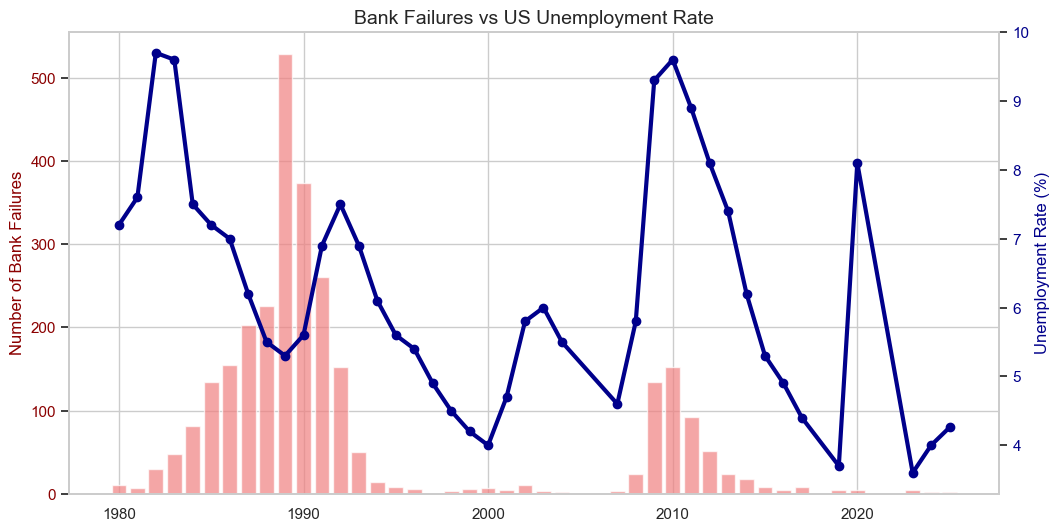

In [ ]:
# Visualizing the relationship between bank failures and unemployment
failures_per_year = df_final.groupby('YEAR').size().reset_index(name='Failures')
macro_df = failures_per_year.merge(annual_unemp, on='YEAR', how='inner')

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(macro_df['YEAR'], macro_df['Failures'], color='lightcoral', alpha=0.7, label='Bank Failures')
ax1.set_ylabel('Number of Bank Failures', color='darkred', fontsize=12)
ax1.tick_params(axis='y', labelcolor='darkred')

ax2 = ax1.twinx()  
ax2.plot(macro_df['YEAR'], macro_df['UNRATE'], color='darkblue', linewidth=3, marker='o', label='Unemployment Rate')
ax2.set_ylabel('Unemployment Rate (%)', color='darkblue', fontsize=12)  
ax2.tick_params(axis='y', labelcolor='darkblue')

plt.title('Bank Failures vs US Unemployment Rate', fontsize=14)
plt.grid(False)
plt.show()

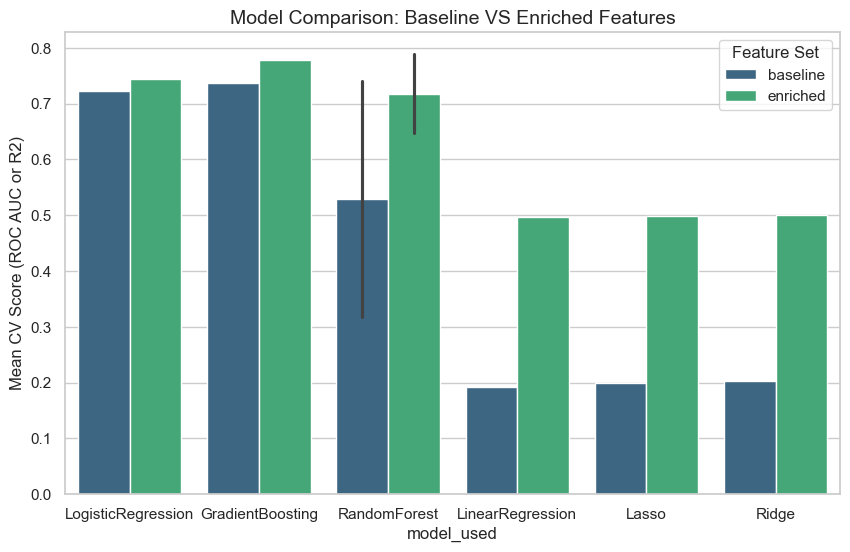

,model_used,feature_set,task,mean_score
5,RandomForest,enriched,classification,0.789052
3,GradientBoosting,enriched,classification,0.777610
1,LogisticRegression,enriched,classification,0.744600
4,RandomForest,baseline,classification,0.740203
2,GradientBoosting,baseline,classification,0.736953
0,LogisticRegression,baseline,classification,0.722929
13,RandomForest,enriched,regression,0.647326
11,Ridge,enriched,regression,0.500990
9,Lasso,enriched,regression,0.499331
7,LinearRegression,enriched,regression,0.496771


In [16]:
# Automatically read all run logs from the outputs directory
output_dir = "outputs"
results_list = []

if os.path.exists(output_dir):
    for sub_dir in os.listdir(output_dir):
        log_path = os.path.join(output_dir, sub_dir, "logs.json")
        if os.path.exists(log_path):
            with open(log_path, "r") as f:
                log_data = json.load(f)
                log_data['run_id'] = sub_dir 
                results_list.append(log_data)

df_results = pd.DataFrame(results_list)

if not df_results.empty:
    plt.figure(figsize=(10, 6))
    
    # --- LA LIGNE CORRIGÉE EST ICI ---
    # On utilise bien df_results, model_used et mean_score (sans legend=False)
    sns.barplot(data=df_results, x='model_used', y='mean_score', hue='feature_set', palette='viridis')
    # ---------------------------------
    
    plt.title('Model Comparison: Baseline VS Enriched Features', fontsize=14)
    plt.ylabel('Mean CV Score (ROC AUC or R2)')
    plt.legend(title='Feature Set') # Maintenant ça marche car sns.barplot a préparé la légende !
    plt.show()
    
    display(df_results[['model_used', 'feature_set', 'task', 'mean_score']].sort_values(by='mean_score', ascending=False))
else:
    print("No logs found. Run main.py to generate models.")

--- Best Model Found ---
Model: RandomForest | Features: enriched | Score: 0.7891


C:\Users\baleh\AppData\Local\Temp\ipykernel_132\3176060239.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance, palette='magma')


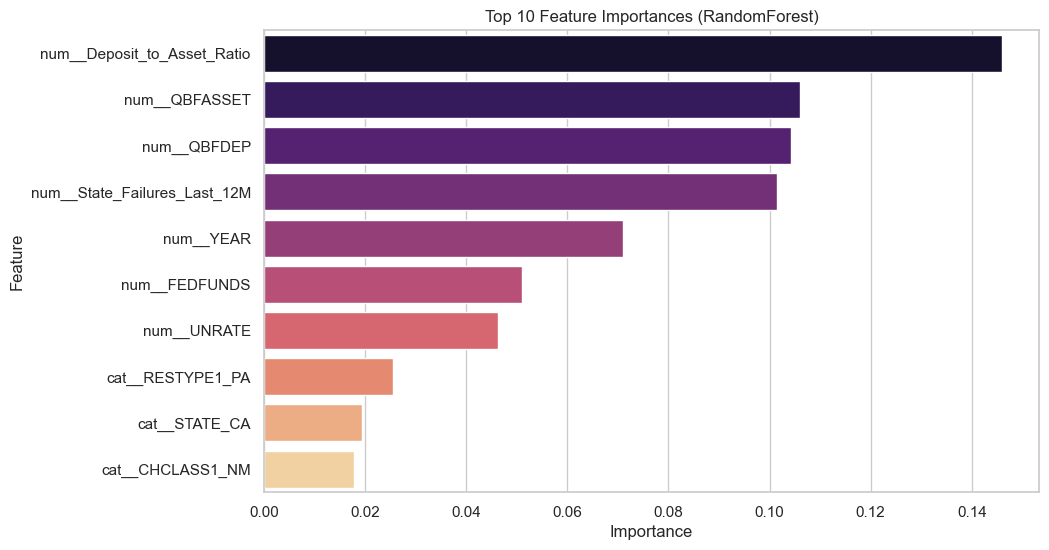

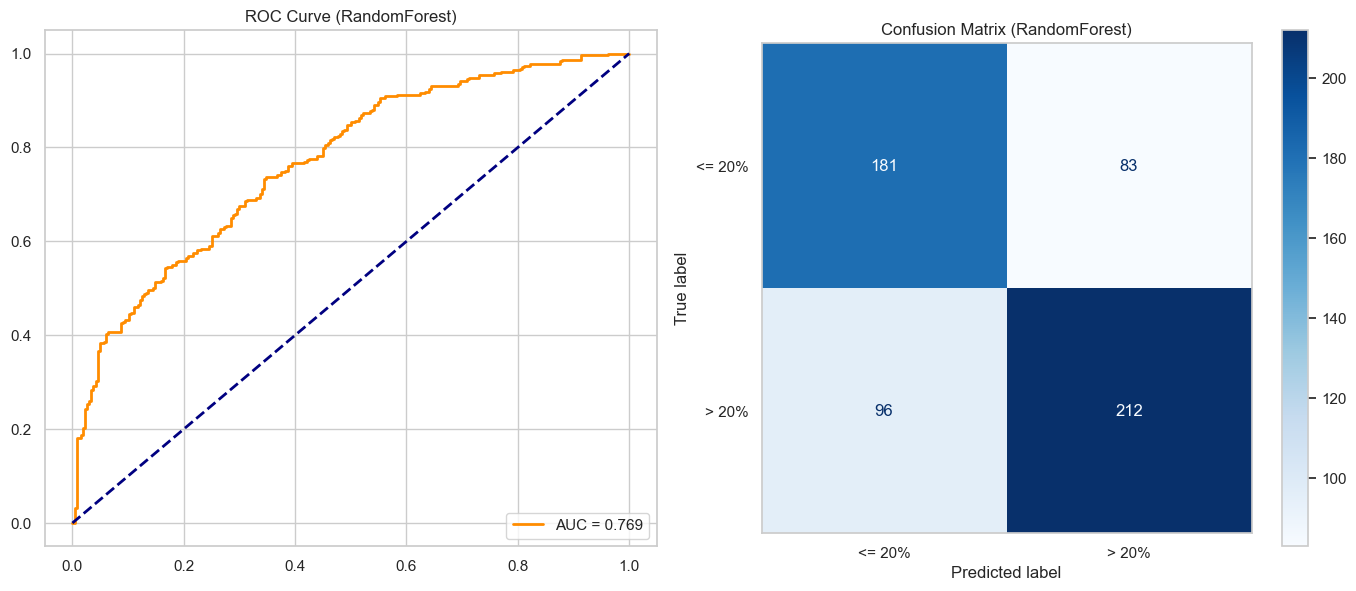

In [ ]:
# Automatically extract and evaluate the best performing model
if not df_results.empty:
    best_idx = df_results['mean_score'].idxmax()
    best_run = df_results.loc[best_idx]
    
    print(f"--- Best Model Found ---")
    print(f"Model: {best_run['model_used']} | Features: {best_run['feature_set']} | Score: {best_run['mean_score']:.4f}")

    model_path = os.path.join(output_dir, best_run['run_id'], "model.pkl")
    
    with open(model_path, 'rb') as f:
        best_pipeline = pickle.load(f)

    # 1. Feature Importance Extraction
    preprocessor = best_pipeline.named_steps['preprocessor']
    ml_model = best_pipeline.named_steps['model']
    feature_names = preprocessor.get_feature_names_out()

    if hasattr(ml_model, 'feature_importances_'):
        importances = ml_model.feature_importances_
    elif hasattr(ml_model, 'coef_'):
        importances = np.abs(ml_model.coef_[0] if len(ml_model.coef_.shape) > 1 else ml_model.coef_)
    else:
        importances = np.zeros(len(feature_names))

    df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    df_importance = df_importance.sort_values(by='Importance', ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=df_importance, palette='magma')
    plt.title(f'Top 10 Feature Importances ({best_run["model_used"]})')
    plt.show()

    # 2. Final Evaluation on isolated Test Set (Recreated with same random_state as main.py)
    num_cols = ['QBFASSET', 'QBFDEP', 'Deposit_to_Asset_Ratio', 'State_Failures_Last_12M', 'YEAR', 'UNRATE', 'FEDFUNDS']
    cat_cols = ['CHCLASS1', 'RESTYPE1', 'SAVR', 'STATE']
    
    X = df_final[num_cols + cat_cols]
    y = df_final['LGD_class'] if best_run['task'] == 'classification' else df_final['LGD']

    if best_run['task'] == 'classification':
        # Re-isolate the test set to avoid data leakage
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        
        y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]
        y_pred = best_pipeline.predict(X_test)

        fig, ax = plt.subplots(1, 2, figsize=(14, 6))

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
        ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        ax[0].set_title(f'ROC Curve ({best_run["model_used"]})')
        ax[0].legend(loc="lower right")

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<= 20%', '> 20%'])
        disp.plot(cmap='Blues', ax=ax[1], values_format='d')
        ax[1].set_title(f'Confusion Matrix ({best_run["model_used"]})')
        ax[1].grid(False)

        plt.tight_layout()
        plt.show()
    else:
        print("Best model is a regression model. ROC and Confusion Matrix are not applicable.")